
Enter signal equation in terms of t:
Example: sin(2*pi*50*t) + 0.5*sin(2*pi*120*t)

x(t) = 10*exp(-2*t)*sin(2*pi*40*t)


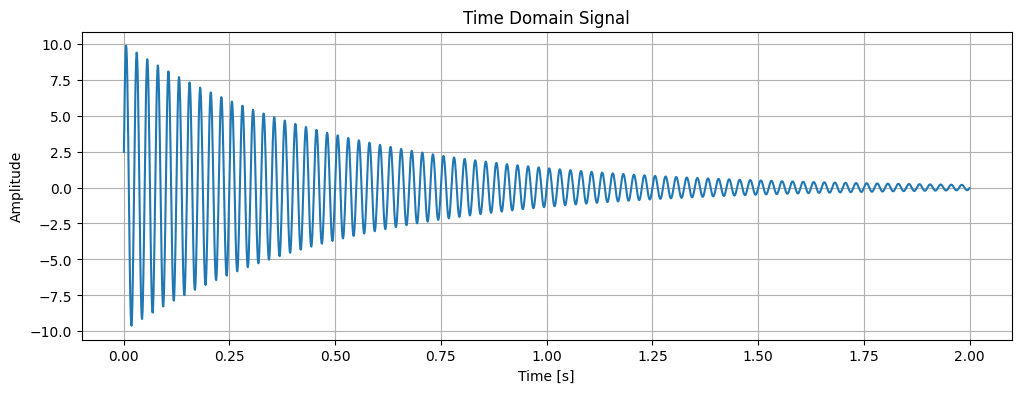

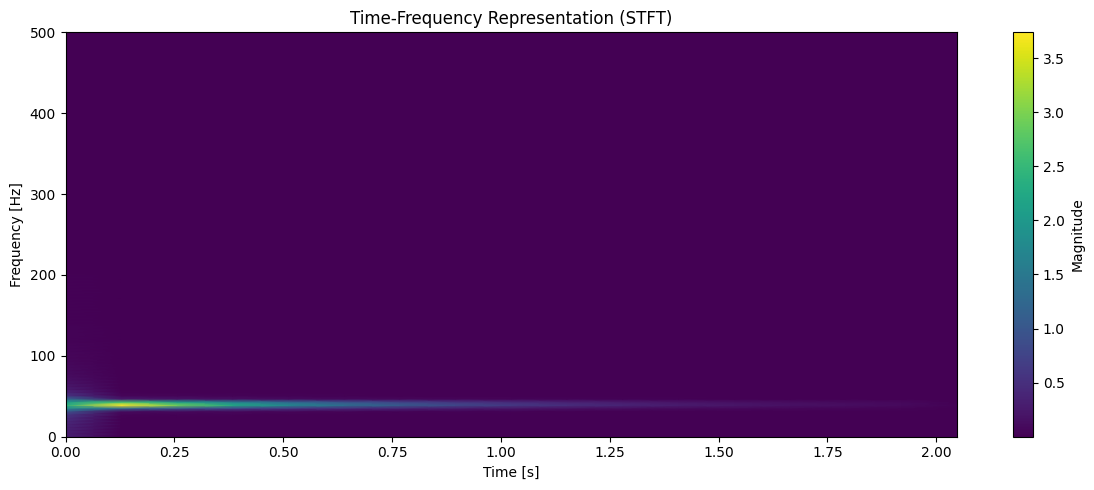

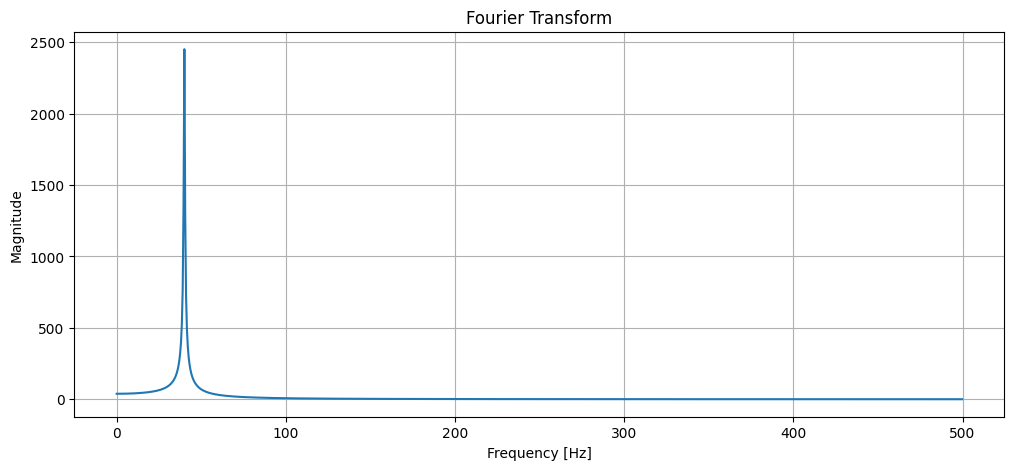


Computing Laplace Transform...


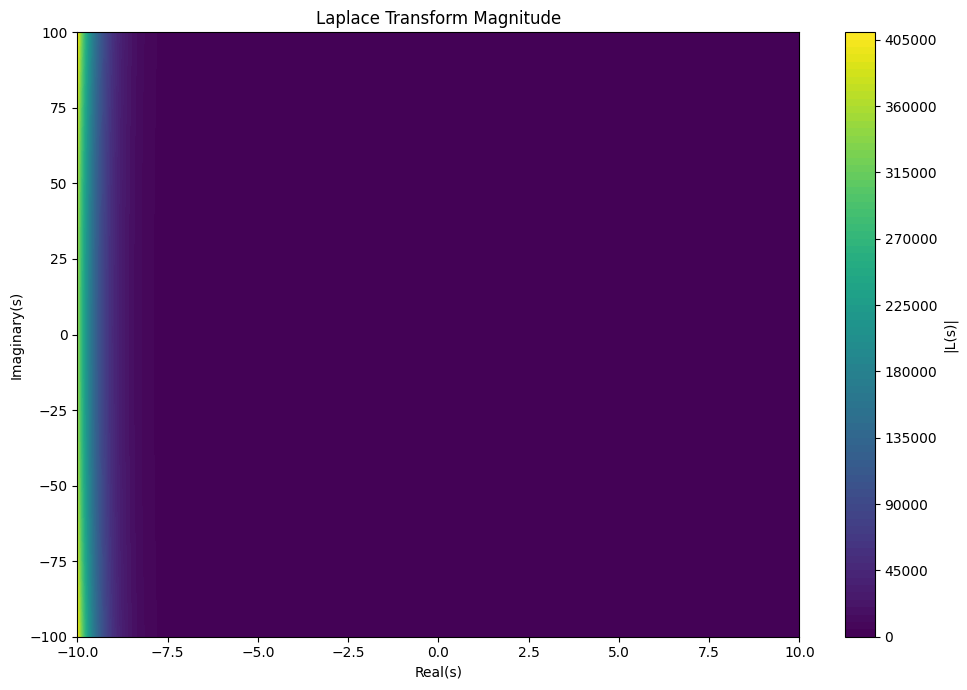


Analysis Complete.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from sympy import (
    symbols,
    sympify,
    lambdify,
    sin,
    cos,
    tan,
    exp,
    log,
    sqrt,
    pi
)


expr_str = input(
    "\nEnter signal equation in terms of t:\n"
    "Example: sin(2*pi*50*t) + 0.5*sin(2*pi*120*t)\n\n"
    "x(t) = "
)

fs = 1000
T = 2
t = np.linspace(1/fs, T, fs*T - int(fs/fs), endpoint=False)
t_sym = symbols('t')
expr = sympify(expr_str)
if t_sym in expr.free_symbols:
    f = lambdify(t_sym, expr, modules=['numpy'])
    x = f(t)
else:
    constant_value = float(expr)
    x = np.full_like(t, constant_value)

plt.figure(figsize=(12, 4))
plt.plot(t, x)

plt.title("Time Domain Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

f_stft, tt, Zxx = signal.stft(
    x,
    fs=fs,
    nperseg=256
)

plt.figure(figsize=(12, 5))

plt.pcolormesh(
    tt,
    f_stft,
    np.abs(Zxx),
    shading='gouraud'
)

plt.title("Time-Frequency Representation (STFT)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label='Magnitude')

plt.tight_layout()
plt.show()

N = len(x)

Xf = fft(x)
freqs = fftfreq(N, 1/fs)

positive = freqs >= 0

plt.figure(figsize=(12, 5))

plt.plot(
    freqs[positive],
    np.abs(Xf[positive])
)

plt.title("Fourier Transform")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True)

plt.show()

sigma = np.linspace(-10, 10, 200)
omega = np.linspace(-100, 100, 200)

SIGMA, OMEGA = np.meshgrid(sigma, omega)

S = SIGMA + 1j*OMEGA

L = np.zeros_like(S, dtype=complex)

print("\nComputing Laplace Transform...")

for i in range(S.shape[0]):
    for j in range(S.shape[1]):

        s = S[i, j]

        integrand = x * np.exp(-s * t)
        L[i, j] = np.trapezoid(integrand, t)

plt.figure(figsize=(10, 7))

plt.contourf(
    SIGMA,
    OMEGA,
    np.abs(L),
    levels=100
)

plt.title("Laplace Transform Magnitude")
plt.xlabel("Real(s)")
plt.ylabel("Imaginary(s)")
plt.colorbar(label='|L(s)|')

plt.tight_layout()
plt.show()

print("\nAnalysis Complete.")


Enter signal x(t):
Example: sin(2*pi*50*t)

x(t) = 1


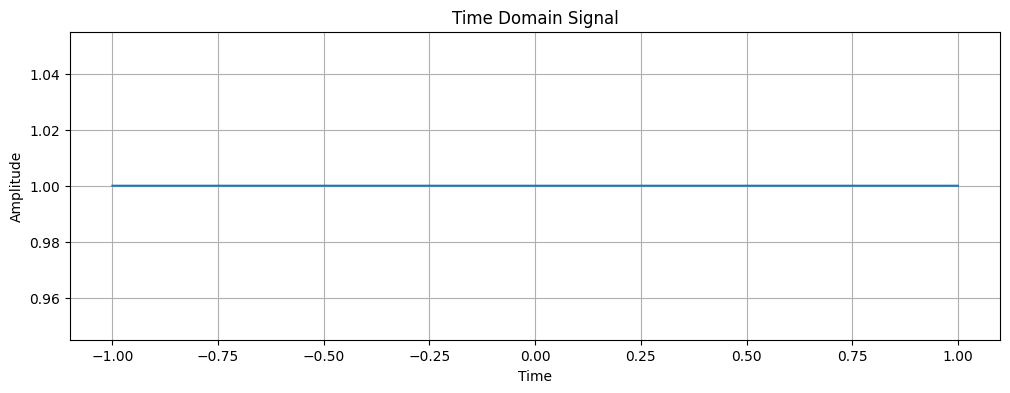

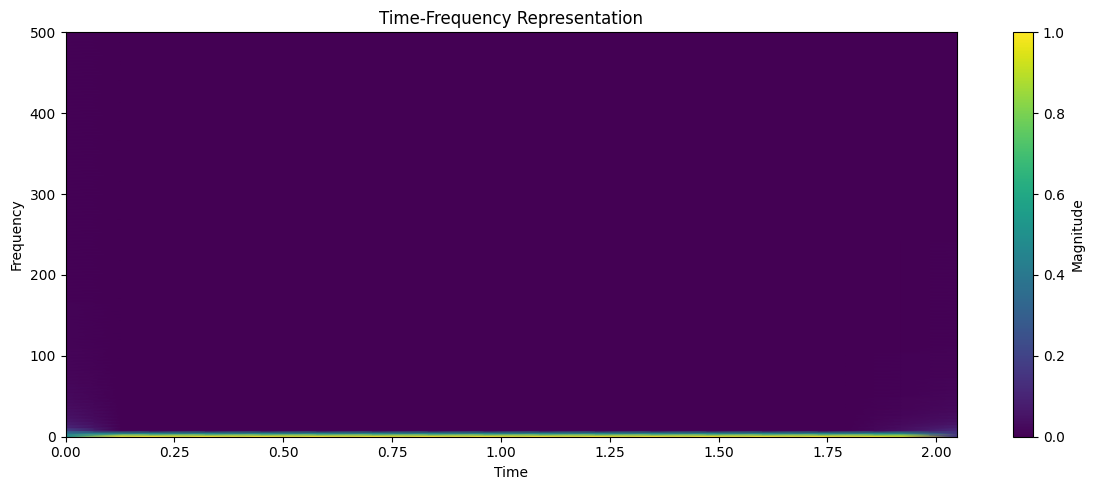

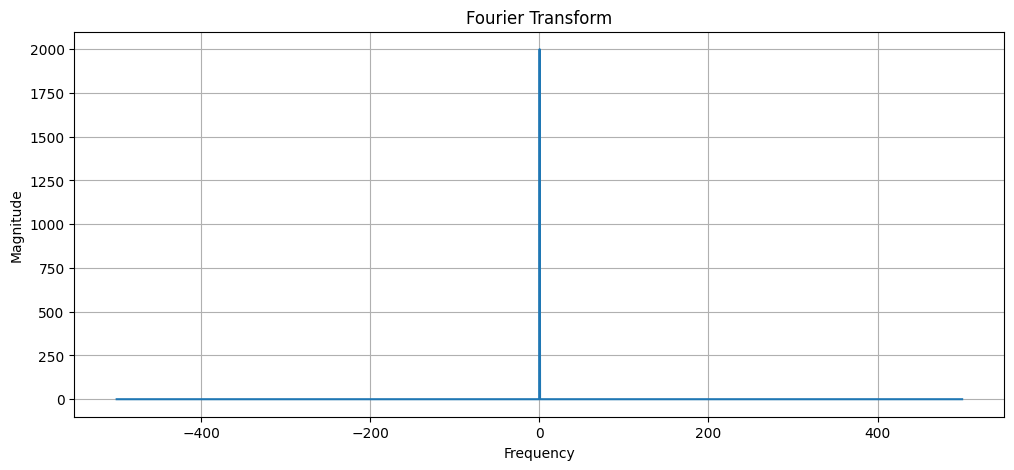


Enter LCT Parameters:
A = 0
B = 1
C = -1
D = 1

Computing LCT...


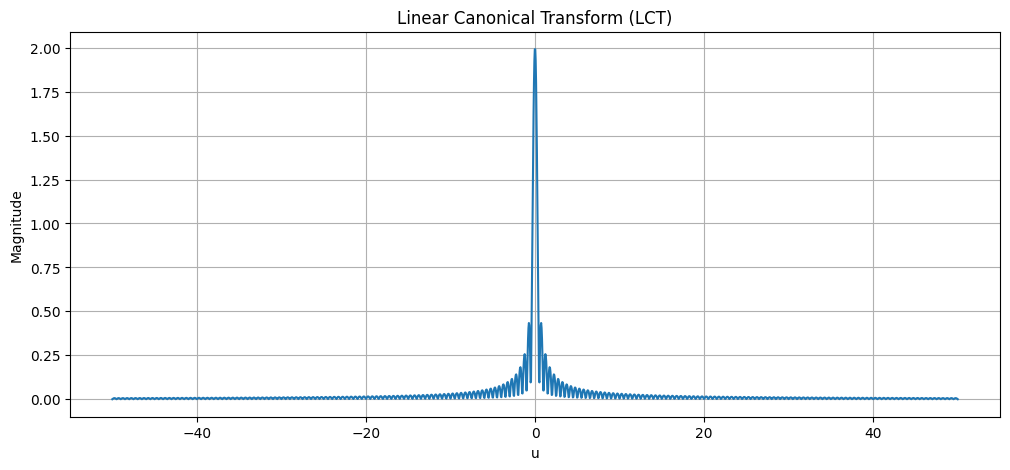


Computing Laplace Transform...


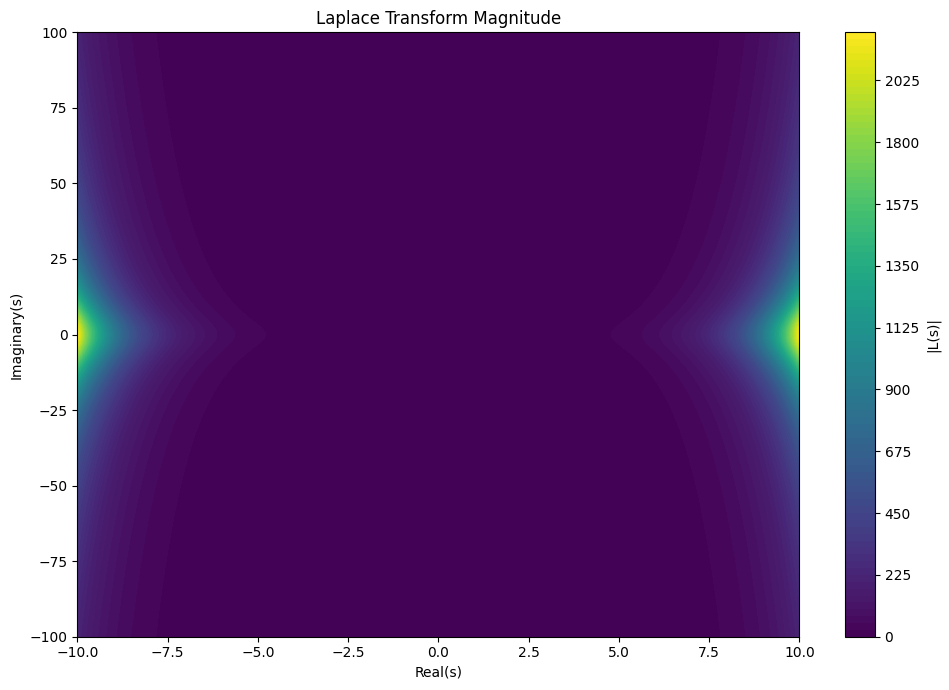


All Analysis Complete.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftshift
from sympy import (
    symbols,
    sympify,
    lambdify,
    sin,
    cos,
    tan,
    exp,
    log,
    sqrt,
    pi
)

expr_str = input(
    "\nEnter signal x(t):\n"
    "Example: sin(2*pi*50*t)\n\n"
    "x(t) = "
)

fs = 1000
T = 2

t = np.linspace(-T/2, T/2, fs*T)

dt = t[1] - t[0]

t_sym = symbols('t')

expr = sympify(expr_str)
if t_sym in expr.free_symbols:
    f = lambdify(t_sym, expr, modules=['numpy'])
    x = f(t)
else:
    constant_value = float(expr)
    x = np.full_like(t, constant_value)

plt.figure(figsize=(12, 4))

plt.plot(t, x)

plt.title("Time Domain Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

f_stft, tt, Zxx = signal.stft(
    x,
    fs=fs,
    nperseg=256
)

plt.figure(figsize=(12, 5))

plt.pcolormesh(
    tt,
    f_stft,
    np.abs(Zxx),
    shading='gouraud'
)

plt.title("Time-Frequency Representation")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label='Magnitude')

plt.tight_layout()
plt.show()

N = len(x)

Xf = fftshift(fft(x))

freqs = np.linspace(-fs/2, fs/2, N)

plt.figure(figsize=(12, 5))

plt.plot(freqs, np.abs(Xf))

plt.title("Fourier Transform")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.grid(True)

plt.show()


print("\nEnter LCT Parameters:")

A = float(input("A = "))
B = float(input("B = "))
C = float(input("C = "))
D = float(input("D = "))

det = A*D - B*C

if abs(det - 1) > 1e-6:
    raise ValueError(
        "\nInvalid LCT Matrix.\n"
        "Condition AD - BC = 1 must hold.")

u = np.linspace(-50, 50, N)

LCT = np.zeros(N, dtype=complex)

print("\nComputing LCT...")

for k in range(N):

    uk = u[k]

    kernel = np.exp(
        1j*np.pi/B * (
            A*t**2
            - 2*t*uk
            + D*uk**2
        )
    )

    LCT[k] = (
        np.sqrt(1/(1j*B))
        * np.trapezoid(x * kernel, t) )

plt.figure(figsize=(12, 5))

plt.plot(u, np.abs(LCT))

plt.title("Linear Canonical Transform (LCT)")
plt.xlabel("u")
plt.ylabel("Magnitude")
plt.grid(True)

plt.show()

sigma = np.linspace(-10, 10, 150)
omega = np.linspace(-100, 100, 150)

SIGMA, OMEGA = np.meshgrid(sigma, omega)

S = SIGMA + 1j*OMEGA

L = np.zeros_like(S, dtype=complex)

print("\nComputing Laplace Transform...")

for i in range(S.shape[0]):
    for j in range(S.shape[1]):

        s = S[i, j]

        integrand = x * np.exp(-s * t)

        L[i, j] = np.trapezoid(integrand, t)

plt.figure(figsize=(10, 7))

plt.contourf(
    SIGMA,
    OMEGA,
    np.abs(L),
    levels=100
)

plt.title("Laplace Transform Magnitude")
plt.xlabel("Real(s)")
plt.ylabel("Imaginary(s)")
plt.colorbar(label='|L(s)|')

plt.tight_layout()
plt.show()

print("\nAll Analysis Complete.")

H(s) = (s+1)/(s**2 + 2*s + 10)


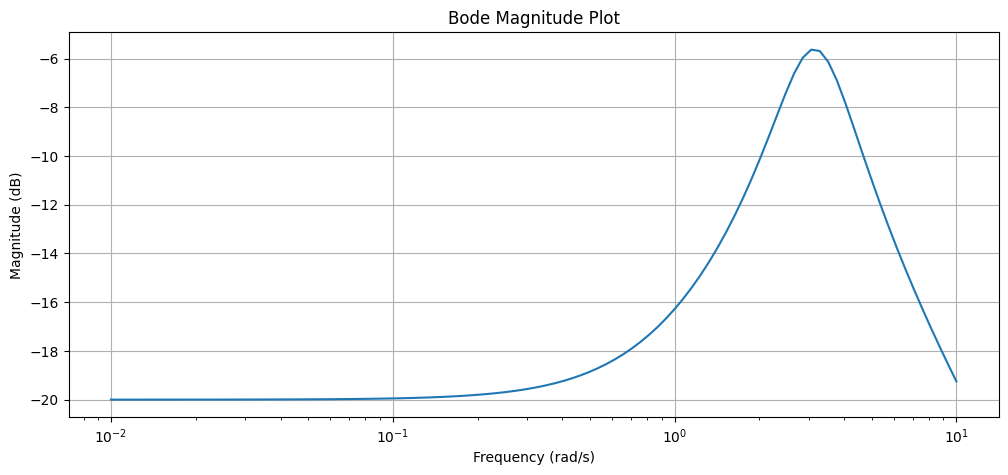

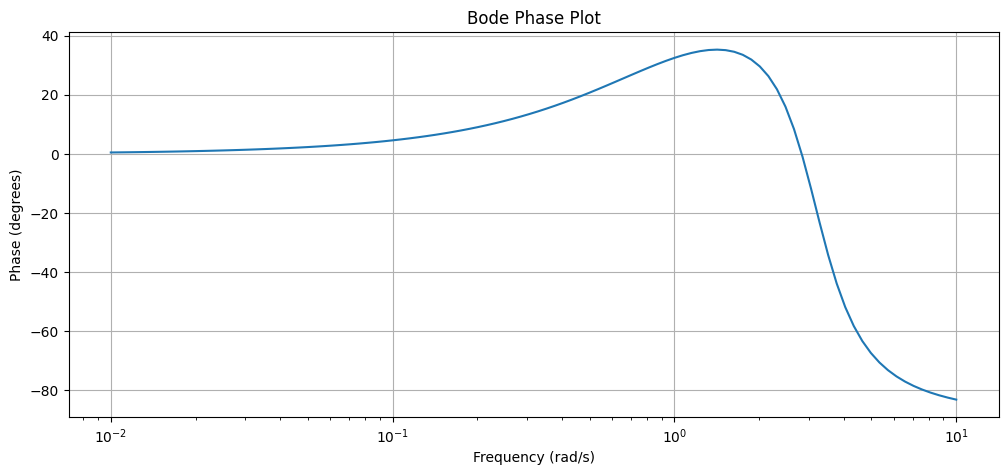

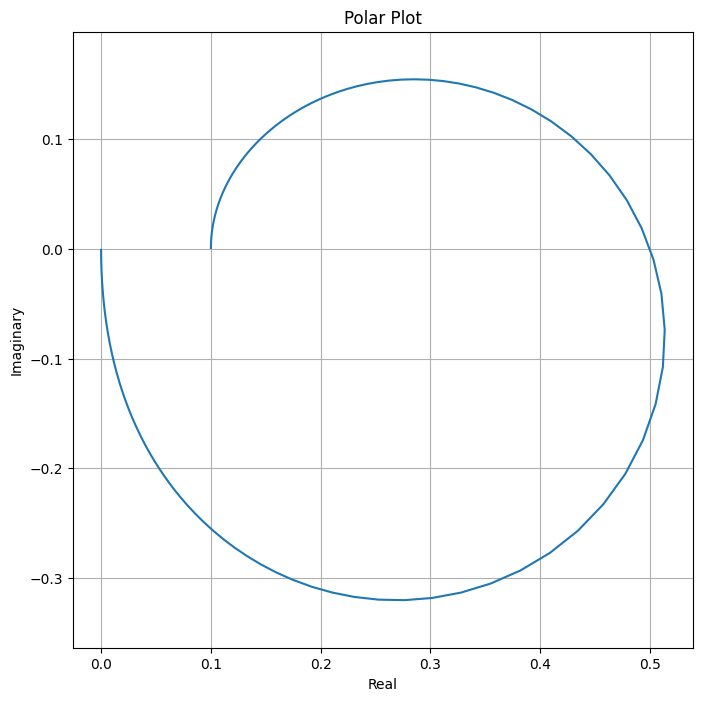

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sympy import symbols, sympify, lambdify, I

s = symbols('s')

expr = input("H(s) = ")

Hs = sympify(expr)

num, den = Hs.as_numer_denom()

num_poly = num.as_poly(s)
den_poly = den.as_poly(s)

num_coeff = [float(c) for c in num_poly.all_coeffs()]
den_coeff = [float(c) for c in den_poly.all_coeffs()]

system = signal.TransferFunction(num_coeff, den_coeff)

w, mag, phase = signal.bode(system)

plt.figure(figsize=(12, 5))
plt.semilogx(w, mag)
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude (dB)")
plt.title("Bode Magnitude Plot")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.semilogx(w, phase)
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Bode Phase Plot")
plt.grid(True)
plt.show()

omega = np.logspace(-2, 3, 500)

Hjw = []

for wv in omega:
    val = Hs.subs(s, I * wv)
    val = complex(val.evalf())
    Hjw.append(val)

Hjw = np.array(Hjw)

plt.figure(figsize=(8, 8))
plt.plot(Hjw.real, Hjw.imag)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Polar Plot")
plt.grid(True)
plt.axis('equal')
plt.show()